# Experiment 5 -- Scalability Analysis (10 Participants)

**PhD Project:** Collaboration Humain-Robot : Apprentissage incremental et adaptation comportementale
**Author:** Ameur Gargouri
**Notebook:** `07_scalability_analysis.ipynb`

## Objective

Test how CL strategies perform with 10 sequential participants. This addresses a key question for real HRC deployment:
**Does the system degrade as more operators use it?**

## Primary Metric: Accuracy (R² + Threshold Accuracy)

- **R² (coefficient of determination):** Proportion of variance explained (1.0 = perfect, 0.0 = mean predictor)
- **Threshold Accuracy:** % of predictions within tolerance (|error| < 0.5 std per joint)
- MSE and BWT remain as secondary metrics

## Strategies tested
- Naive Fine-Tune (lower bound)
- Joint Training (upper bound)
- DER++ (buffer=10000, best incremental)
- Online EWC (lambda=10000, gamma=0.99, best regularization)
- A-GEM (mem_per_task=256, gradient projection)

---

In [1]:
import os, sys, abc, copy, json, logging, random, time, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Any, Optional
from itertools import product

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import ConcatDataset, DataLoader, TensorDataset

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING, format='%(message)s')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} -- device: {DEVICE}')
if DEVICE == 'cuda': print(f'  GPU: {torch.cuda.get_device_name()}')

PROJECT_ROOT = "/home/g0amer/Desktop/thesis/phd_project/thesis_project"
HARMONIC_DIR = f'{PROJECT_ROOT}/data/processed/harmonic'
RESULTS_DIR  = f'{PROJECT_ROOT}/experiments/exp05_scalability'
os.makedirs(RESULTS_DIR, exist_ok=True)

participants = sorted([d for d in os.listdir(HARMONIC_DIR)
                       if os.path.isdir(os.path.join(HARMONIC_DIR, d)) and d.startswith('p')])
print(f'Available participants: {len(participants)} -> {participants}')
print(f'Results: {RESULTS_DIR}')

PyTorch 2.10.0+cu128 -- device: cuda
  GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Available participants: 24 -> ['p100', 'p101', 'p102', 'p103', 'p104', 'p105', 'p106', 'p107', 'p108', 'p109', 'p110', 'p111', 'p112', 'p113', 'p114', 'p115', 'p116', 'p117', 'p118', 'p119', 'p120', 'p121', 'p122', 'p123']
Results: /home/g0amer/Desktop/thesis/phd_project/thesis_project/experiments/exp05_scalability


In [2]:
# Metrics & Data Structures

ACCURACY_THRESHOLD = 0.5  # threshold for accuracy: |error| < 0.5 (in normalized space)

@dataclass
class TaskResult:
    task_id: int; loss: float; mse: float; mae: float; r2: float
    n_samples: int = 0
    per_dim_mse: list = field(default_factory=list)
    threshold_accuracy: float = 0.0  # % predictions within tolerance
    ss_res: float = 0.0              # sum of squared residuals (for pooled R²)
    ss_tot: float = 0.0              # total sum of squares (for pooled R²)
    n_correct: int = 0               # samples within threshold (for pooled accuracy)

@dataclass
class ContinualMetrics:
    n_tasks: int = 0
    accuracy_matrix: list = field(default_factory=list)   # MSE matrix
    r2_matrix: list = field(default_factory=list)          # R² matrix
    acc_matrix: list = field(default_factory=list)         # threshold accuracy matrix
    task_names: list = field(default_factory=list)
    per_dim_matrix: list = field(default_factory=list)
    _last_results: list = field(default_factory=list)      # raw TaskResults for pooled metrics

    def record(self, trained_up_to, task_results):
        mse_row = [r.mse for r in task_results]
        r2_row = [r.r2 for r in task_results]
        acc_row = [r.threshold_accuracy for r in task_results]
        while len(self.accuracy_matrix) <= trained_up_to:
            self.accuracy_matrix.append([])
            self.r2_matrix.append([])
            self.acc_matrix.append([])
            self.per_dim_matrix.append([])
        self.accuracy_matrix[trained_up_to] = mse_row
        self.r2_matrix[trained_up_to] = r2_row
        self.acc_matrix[trained_up_to] = acc_row
        self.per_dim_matrix[trained_up_to] = [r.per_dim_mse for r in task_results]
        self._last_results = task_results  # keep latest for pooled metrics

    @property
    def average_mse(self):
        if not self.accuracy_matrix: return float('nan')
        last = self.accuracy_matrix[-1]
        return float(np.mean(last)) if last else float('nan')

    @property
    def average_r2(self):
        if not self.r2_matrix: return float('nan')
        last = self.r2_matrix[-1]
        return float(np.mean(last)) if last else float('nan')

    @property
    def average_threshold_accuracy(self):
        if not self.acc_matrix: return float('nan')
        last = self.acc_matrix[-1]
        return float(np.mean(last)) if last else float('nan')

    @property
    def overall_r2(self):
        """Pooled R² across ALL test samples (sample-weighted)."""
        if not self._last_results: return float('nan')
        ss_res = sum(r.ss_res for r in self._last_results)
        ss_tot = sum(r.ss_tot for r in self._last_results)
        return 1 - ss_res / max(ss_tot, 1e-8)

    @property
    def overall_threshold_accuracy(self):
        """Pooled threshold accuracy across ALL test samples."""
        if not self._last_results: return float('nan')
        total_correct = sum(r.n_correct for r in self._last_results)
        total_samples = sum(r.n_samples for r in self._last_results)
        return total_correct / max(total_samples, 1) * 100

    @property
    def backward_transfer(self):
        T = len(self.accuracy_matrix)
        if T < 2: return 0.0
        bwt, cnt = 0.0, 0
        for j in range(T - 1):
            if j < len(self.accuracy_matrix[T-1]) and j < len(self.accuracy_matrix[j]):
                bwt += self.accuracy_matrix[T-1][j] - self.accuracy_matrix[j][j]; cnt += 1
        return bwt / cnt if cnt > 0 else 0.0

    @property
    def r2_backward_transfer(self):
        """BWT for R²: positive = improvement, negative = forgetting."""
        T = len(self.r2_matrix)
        if T < 2: return 0.0
        bwt, cnt = 0.0, 0
        for j in range(T - 1):
            if j < len(self.r2_matrix[T-1]) and j < len(self.r2_matrix[j]):
                bwt += self.r2_matrix[T-1][j] - self.r2_matrix[j][j]; cnt += 1
        return bwt / cnt if cnt > 0 else 0.0

    @property
    def forward_transfer(self):
        T = len(self.accuracy_matrix)
        if T < 2: return 0.0
        fwt, cnt = 0.0, 0
        for j in range(1, T):
            if j < len(self.accuracy_matrix[j-1]) and j < len(self.accuracy_matrix[j]):
                fwt += self.accuracy_matrix[j-1][j] - self.accuracy_matrix[j][j]; cnt += 1
        return fwt / cnt if cnt > 0 else 0.0

    def summary_dict(self):
        return {'n_tasks': len(self.accuracy_matrix),
                'average_mse': self.average_mse,
                'average_r2': self.average_r2,
                'average_threshold_accuracy': self.average_threshold_accuracy,
                'overall_r2': self.overall_r2,
                'overall_threshold_accuracy': self.overall_threshold_accuracy,
                'backward_transfer': self.backward_transfer,
                'r2_backward_transfer': self.r2_backward_transfer,
                'forward_transfer': self.forward_transfer,
                'accuracy_matrix': self.accuracy_matrix,
                'r2_matrix': self.r2_matrix,
                'acc_matrix': self.acc_matrix,
                'task_names': self.task_names,
                'per_dim_matrix': self.per_dim_matrix}

@dataclass
class TaskData:
    task_id: int; participant_id: str
    obs_train: torch.Tensor; act_train: torch.Tensor
    obs_val: torch.Tensor; act_val: torch.Tensor
    obs_test: torch.Tensor; act_test: torch.Tensor

    @property
    def n_train(self): return self.obs_train.shape[0]
    @property
    def n_val(self): return self.obs_val.shape[0]
    @property
    def n_test(self): return self.obs_test.shape[0]
    def train_loader(self, bs=256):
        return DataLoader(TensorDataset(self.obs_train, self.act_train), batch_size=bs, shuffle=True)
    def val_loader(self, bs=512):
        return DataLoader(TensorDataset(self.obs_val, self.act_val), batch_size=bs)
    def test_loader(self, bs=512):
        return DataLoader(TensorDataset(self.obs_test, self.act_test), batch_size=bs)

print('Metrics & TaskData defined')
print(f'  Accuracy threshold: |error| < {ACCURACY_THRESHOLD} (normalized units)')
print(f'  Overall accuracy: pooled R² and threshold accuracy across all test samples')

Metrics & TaskData defined
  Accuracy threshold: |error| < 0.5 (normalized units)
  Overall accuracy: pooled R² and threshold accuracy across all test samples


In [3]:
# Model & CL Strategies (SI dropped, A-GEM added)

class MLPPolicy(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=(256,256), dropout=0.1):
        super().__init__()
        layers = []
        d = obs_dim
        for h in hidden:
            layers += [nn.Linear(d,h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        layers.append(nn.Linear(d, act_dim))
        self.net = nn.Sequential(*layers)
        self.obs_dim, self.act_dim = obs_dim, act_dim
    def forward(self, x): return self.net(x)

class ContinualLearner(abc.ABC):
    def __init__(self, model, lr=1e-3, weight_decay=0., device='cpu'):
        self.model = model.to(device); self.device = device; self.lr = lr
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        self._current_task = -1
    @abc.abstractmethod
    def on_task_start(self, task_id, train_loader): ...
    @abc.abstractmethod
    def compute_loss(self, obs, act, task_id): ...
    @abc.abstractmethod
    def on_task_end(self, task_id, train_loader): ...

    def train_task(self, task_id, train_loader, val_loader=None, epochs=50, patience=10, verbose=False):
        self._current_task = task_id
        self.on_task_start(task_id, train_loader)
        self.model.train()
        best_val, best_state, no_improve = float('inf'), None, 0
        history = {'train_loss': [], 'val_loss': []}
        for epoch in range(epochs):
            eloss, nb = 0., 0
            for batch in train_loader:
                obs, act = batch[0].to(self.device), batch[1].to(self.device)
                self.optimizer.zero_grad()
                loss = self.compute_loss(obs, act, task_id)
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
                eloss += loss.item(); nb += 1
            avg = eloss / max(nb, 1)
            history['train_loss'].append(avg)
            if val_loader is not None:
                vl = self._eval_loss(val_loader)
                history['val_loss'].append(vl)
                if vl < best_val:
                    best_val = vl; best_state = copy.deepcopy(self.model.state_dict()); no_improve = 0
                else: no_improve += 1
                if no_improve >= patience: break
        if best_state is not None: self.model.load_state_dict(best_state)
        self.on_task_end(task_id, train_loader)
        return history

    def _eval_loss(self, loader):
        self.model.eval()
        tot, n = 0., 0
        with torch.no_grad():
            for b in loader:
                o, a = b[0].to(self.device), b[1].to(self.device)
                tot += F.mse_loss(self.model(o), a).item() * o.size(0); n += o.size(0)
        self.model.train()
        return tot / max(n, 1)

    def evaluate_task(self, test_loader, task_id):
        self.model.eval()
        preds, tgts = [], []
        with torch.no_grad():
            for b in test_loader:
                o, a = b[0].to(self.device), b[1].to(self.device)
                preds.append(self.model(o).cpu()); tgts.append(a.cpu())
        p, t = torch.cat(preds), torch.cat(tgts)
        mse = F.mse_loss(p, t).item()
        mae = (p - t).abs().mean().item()
        ss_res = ((t - p)**2).sum().item()
        ss_tot = ((t - t.mean(0))**2).sum().item()
        r2 = 1 - ss_res / max(ss_tot, 1e-8)
        per_dim = ((p - t)**2).mean(0).tolist()
        # Threshold accuracy: % of samples where ALL dimensions are within tolerance
        errors = (p - t).abs()
        correct_mask = (errors < ACCURACY_THRESHOLD).all(dim=1)
        within_threshold = correct_mask.float().mean().item() * 100
        n_correct = int(correct_mask.sum().item())
        self.model.train()
        return TaskResult(task_id, mse, mse, mae, r2, len(t), per_dim, within_threshold,
                          ss_res, ss_tot, n_correct)

# --- 1. Naive Fine-Tune ---
class NaiveFineTune(ContinualLearner):
    def on_task_start(self, t, l): pass
    def compute_loss(self, obs, act, t): return F.mse_loss(self.model(obs), act)
    def on_task_end(self, t, l): pass

# --- 2. Joint Training ---
class JointTraining(ContinualLearner):
    def __init__(self, model, lr=1e-3, device='cpu'):
        super().__init__(model, lr=lr, device=device)
        self._datasets = {}; self._init_state = copy.deepcopy(model.state_dict())
    def on_task_start(self, task_id, train_loader):
        all_o, all_a = [], []
        for b in train_loader: all_o.append(b[0]); all_a.append(b[1])
        self._datasets[task_id] = TensorDataset(torch.cat(all_o), torch.cat(all_a))
        self.model.load_state_dict(copy.deepcopy(self._init_state))
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
    def compute_loss(self, obs, act, t): return F.mse_loss(self.model(obs), act)
    def on_task_end(self, t, l): pass
    def train_task(self, task_id, train_loader, val_loader=None, epochs=50, patience=10, verbose=False):
        self._current_task = task_id
        self.on_task_start(task_id, train_loader)
        joint_ds = ConcatDataset(list(self._datasets.values()))
        bs = train_loader.batch_size if hasattr(train_loader, 'batch_size') else 256
        joint_loader = DataLoader(joint_ds, batch_size=bs, shuffle=True)
        self.model.train()
        return super().train_task(task_id, joint_loader, val_loader, epochs, patience, verbose)

# --- 3. EWC (tuned: lambda=10000) ---
class EWC(ContinualLearner):
    def __init__(self, model, lr=1e-3, device='cpu', ewc_lambda=10000., fisher_samples=1000,
                 online=False, gamma=0.99):
        super().__init__(model, lr=lr, device=device)
        self.ewc_lambda = ewc_lambda; self.fisher_samples = fisher_samples
        self.online = online; self.gamma = gamma
        self._fishers = []; self._opt_params = []
        self._run_fisher = None; self._run_params = None
    def on_task_start(self, t, l): pass
    def compute_loss(self, obs, act, task_id):
        loss = F.mse_loss(self.model(obs), act)
        if task_id == 0: return loss
        return loss + self._penalty()
    def on_task_end(self, task_id, train_loader):
        fisher = self._compute_fisher(train_loader)
        if self.online:
            if self._run_fisher is None: self._run_fisher = fisher
            else:
                for n in self._run_fisher:
                    self._run_fisher[n] = self.gamma * self._run_fisher[n] + fisher[n]
            self._run_params = {n: p.clone().detach() for n, p in self.model.named_parameters() if p.requires_grad}
        else:
            self._fishers.append(fisher)
            self._opt_params.append({n: p.clone().detach() for n, p in self.model.named_parameters() if p.requires_grad})
    def _compute_fisher(self, loader):
        fisher = {n: torch.zeros_like(p) for n, p in self.model.named_parameters() if p.requires_grad}
        self.model.eval(); ns = 0
        for b in loader:
            o, a = b[0].to(self.device), b[1].to(self.device)
            self.model.zero_grad()
            F.mse_loss(self.model(o), a).backward()
            for n, p in self.model.named_parameters():
                if p.requires_grad and p.grad is not None:
                    fisher[n] += p.grad.data.pow(2) * o.size(0)
            ns += o.size(0)
            if ns >= self.fisher_samples: break
        for n in fisher: fisher[n] /= max(ns, 1)
        self.model.train()
        return fisher
    def _penalty(self):
        pen = torch.tensor(0., device=self.device)
        if self.online and self._run_fisher is not None:
            for n, p in self.model.named_parameters():
                if n in self._run_fisher:
                    pen += (self._run_fisher[n] * (p - self._run_params[n]).pow(2)).sum()
        else:
            for fi, op in zip(self._fishers, self._opt_params):
                for n, p in self.model.named_parameters():
                    if n in fi: pen += (fi[n] * (p - op[n]).pow(2)).sum()
        return (self.ewc_lambda / 2.) * pen

# --- 4. LwF ---
class LwF(ContinualLearner):
    def __init__(self, model, lr=1e-3, device='cpu', lwf_alpha=1.0):
        super().__init__(model, lr=lr, device=device)
        self.lwf_alpha = lwf_alpha; self._teacher = None
    def on_task_start(self, task_id, train_loader):
        if task_id > 0:
            self._teacher = copy.deepcopy(self.model); self._teacher.eval()
            for p in self._teacher.parameters(): p.requires_grad = False
        else: self._teacher = None
    def compute_loss(self, obs, act, task_id):
        pred = self.model(obs); loss = F.mse_loss(pred, act)
        if self._teacher is not None and task_id > 0:
            with torch.no_grad(): teacher_pred = self._teacher(obs)
            loss = loss + self.lwf_alpha * F.mse_loss(pred, teacher_pred)
        return loss
    def on_task_end(self, t, l): pass

# --- 5. DER++ (tuned: buffer=10000) ---
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.capacity = capacity; self.obs, self.act, self.logits = [], [], []; self._n = 0
    def __len__(self): return len(self.obs)
    def add(self, obs, act, logits):
        for i in range(obs.size(0)):
            self._n += 1
            if len(self.obs) < self.capacity:
                self.obs.append(obs[i].cpu()); self.act.append(act[i].cpu()); self.logits.append(logits[i].cpu())
            else:
                j = random.randint(0, self._n - 1)
                if j < self.capacity:
                    self.obs[j] = obs[i].cpu(); self.act[j] = act[i].cpu(); self.logits[j] = logits[i].cpu()
    def sample(self, n):
        n = min(n, len(self.obs)); idx = random.sample(range(len(self.obs)), n)
        return (torch.stack([self.obs[i] for i in idx]),
                torch.stack([self.act[i] for i in idx]),
                torch.stack([self.logits[i] for i in idx]))

class DERPlusPlus(ContinualLearner):
    def __init__(self, model, lr=1e-3, device='cpu', buffer_size=10000, alpha=0.5, beta=0.5):
        super().__init__(model, lr=lr, device=device)
        self.buffer = ReplayBuffer(buffer_size); self.alpha = alpha; self.beta = beta
    def on_task_start(self, t, l): pass
    def compute_loss(self, obs, act, task_id):
        pred = self.model(obs); loss = F.mse_loss(pred, act)
        with torch.no_grad(): logits = self.model(obs).detach()
        self.buffer.add(obs.detach(), act.detach(), logits)
        if len(self.buffer) > 0 and task_id > 0:
            bo, ba, bl = self.buffer.sample(max(1, obs.size(0)))
            bo, ba, bl = bo.to(self.device), ba.to(self.device), bl.to(self.device)
            bp = self.model(bo)
            loss = loss + self.alpha * F.mse_loss(bp, bl) + self.beta * F.mse_loss(bp, ba)
        return loss
    def on_task_end(self, t, l): pass

# --- 6. A-GEM (Averaged Gradient Episodic Memory) ---
class EpisodicMemory:
    def __init__(self, capacity_per_task=256):
        self.capacity = capacity_per_task
        self.memories = {}

    def store(self, task_id, train_loader):
        all_o, all_a = [], []
        for b in train_loader:
            all_o.append(b[0]); all_a.append(b[1])
        obs = torch.cat(all_o); act = torch.cat(all_a)
        if len(obs) > self.capacity:
            idx = torch.randperm(len(obs))[:self.capacity]
            obs, act = obs[idx], act[idx]
        self.memories[task_id] = (obs, act)

    def get_batch(self):
        if not self.memories:
            return None, None
        all_o = [v[0] for v in self.memories.values()]
        all_a = [v[1] for v in self.memories.values()]
        return torch.cat(all_o), torch.cat(all_a)

class AGEM(ContinualLearner):
    def __init__(self, model, lr=1e-3, device='cpu', mem_per_task=256):
        super().__init__(model, lr=lr, device=device)
        self.memory = EpisodicMemory(mem_per_task)

    def on_task_start(self, task_id, train_loader): pass

    def compute_loss(self, obs, act, task_id):
        return F.mse_loss(self.model(obs), act)

    def on_task_end(self, task_id, train_loader):
        self.memory.store(task_id, train_loader)

    def train_task(self, task_id, train_loader, val_loader=None, epochs=50, patience=10, verbose=False):
        self._current_task = task_id
        self.on_task_start(task_id, train_loader)
        self.model.train()
        best_val, best_state, no_improve = float('inf'), None, 0
        history = {'train_loss': [], 'val_loss': []}

        for epoch in range(epochs):
            eloss, nb = 0., 0
            for batch in train_loader:
                obs, act = batch[0].to(self.device), batch[1].to(self.device)
                self.optimizer.zero_grad()
                loss = self.compute_loss(obs, act, task_id)
                loss.backward()

                if task_id > 0:
                    g = torch.cat([p.grad.data.view(-1) for p in self.model.parameters() if p.grad is not None])
                    mem_o, mem_a = self.memory.get_batch()
                    if mem_o is not None:
                        mem_o, mem_a = mem_o.to(self.device), mem_a.to(self.device)
                        self.optimizer.zero_grad()
                        ref_loss = F.mse_loss(self.model(mem_o), mem_a)
                        ref_loss.backward()
                        g_ref = torch.cat([p.grad.data.view(-1) for p in self.model.parameters() if p.grad is not None])
                        dot = (g * g_ref).sum()
                        if dot < 0:
                            g = g - (dot / (g_ref.norm()**2 + 1e-8)) * g_ref
                        offset = 0
                        for p in self.model.parameters():
                            if p.grad is not None:
                                numel = p.grad.numel()
                                p.grad.data.copy_(g[offset:offset+numel].view_as(p.grad))
                                offset += numel

                nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
                eloss += loss.item(); nb += 1

            avg = eloss / max(nb, 1)
            history['train_loss'].append(avg)
            if val_loader is not None:
                vl = self._eval_loss(val_loader)
                history['val_loss'].append(vl)
                if vl < best_val:
                    best_val = vl; best_state = copy.deepcopy(self.model.state_dict()); no_improve = 0
                else: no_improve += 1
                if no_improve >= patience: break
        if best_state is not None: self.model.load_state_dict(best_state)
        self.on_task_end(task_id, train_loader)
        return history

print('Strategies defined: Naive, Joint, EWC, Online EWC, LwF, DER++, A-GEM')
print('  SI dropped (degenerate on this task)')
print('  A-GEM added (Chaudhry et al., ICLR 2019)')

Strategies defined: Naive, Joint, EWC, Online EWC, LwF, DER++, A-GEM
  SI dropped (degenerate on this task)
  A-GEM added (Chaudhry et al., ICLR 2019)


In [4]:
# Data Loading -- with outlier fix for mico_joint_6_pos

JOY_COLS   = ['axes_x', 'axes_y', 'axes_z']
JPOS_COLS  = [f'mico_joint_{i}_pos' for i in range(1, 7)]
EE_COLS    = ['mico_end_effector_x', 'mico_end_effector_y', 'mico_end_effector_z']
JVEL_COLS  = [f'mico_joint_{i}_vel' for i in range(1, 7)]
OBS_COLS   = JOY_COLS + JPOS_COLS + EE_COLS   # 12 input features
TARGET_COLS = JVEL_COLS                         # 6 output features
JOINT_POS_CLIP = 50.0

def load_participant(processed_dir, participant, val_ratio=0.15, seed=42):
    pdir = Path(processed_dir) / participant
    assert pdir.exists(), f'Not found: {pdir}'

    all_obs, all_tgt = [], []
    for trial_dir in sorted(pdir.iterdir()):
        if not trial_dir.is_dir():
            continue
        joy_path  = trial_dir / 'ada_joy.parquet'
        jpos_path = trial_dir / 'joint_positions.parquet'
        rpos_path = trial_dir / 'robot_position.parquet'
        if not all(p.exists() for p in [joy_path, jpos_path, rpos_path]):
            continue
        df_joy  = pd.read_parquet(joy_path)
        df_jpos = pd.read_parquet(jpos_path)
        df_rpos = pd.read_parquet(rpos_path)
        n = min(len(df_joy), len(df_jpos), len(df_rpos))
        if n < 10:
            continue

        # Outlier fix: clip extreme joint position values
        for col_name in JPOS_COLS:
            if col_name in df_jpos.columns:
                mask = df_jpos[col_name].abs() > JOINT_POS_CLIP
                if mask.any():
                    median_val = df_jpos.loc[~mask, col_name].median()
                    df_jpos.loc[mask, col_name] = median_val

        obs_parts = []
        for cols, df in [(JOY_COLS, df_joy), (JPOS_COLS, df_jpos), (EE_COLS, df_rpos)]:
            available = [c for c in cols if c in df.columns]
            if len(available) != len(cols):
                break
            obs_parts.append(df[available].values[:n])
        else:
            tgt_available = [c for c in JVEL_COLS if c in df_jpos.columns]
            if len(tgt_available) != len(JVEL_COLS):
                continue
            tgt_arr = df_jpos[tgt_available].values[:n]
            obs_arr = np.concatenate(obs_parts, axis=1)
            valid = ~(np.isnan(obs_arr).any(1) | np.isnan(tgt_arr).any(1))
            obs_arr, tgt_arr = obs_arr[valid], tgt_arr[valid]
            if len(obs_arr) > 0:
                all_obs.append(obs_arr)
                all_tgt.append(tgt_arr)
            continue
        continue

    assert all_obs, f'No data for {participant}'
    obs = np.nan_to_num(np.concatenate(all_obs).astype(np.float32))
    tgt = np.nan_to_num(np.concatenate(all_tgt).astype(np.float32))

    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(obs))
    nv = int(len(obs) * val_ratio)
    nt = nv
    obs_t, tgt_t = torch.from_numpy(obs), torch.from_numpy(tgt)
    return (obs_t[idx[nt+nv:]], tgt_t[idx[nt+nv:]],
            obs_t[idx[nt:nt+nv]], tgt_t[idx[nt:nt+nv]],
            obs_t[idx[:nt]],     tgt_t[idx[:nt]])

print(f'load_participant defined (outlier clipping at |val|>{JOINT_POS_CLIP})')
print(f'  Obs ({len(OBS_COLS)}): {OBS_COLS}')
print(f'  Tgt ({len(TARGET_COLS)}): {TARGET_COLS}')

load_participant defined (outlier clipping at |val|>50.0)
  Obs (12): ['axes_x', 'axes_y', 'axes_z', 'mico_joint_1_pos', 'mico_joint_2_pos', 'mico_joint_3_pos', 'mico_joint_4_pos', 'mico_joint_5_pos', 'mico_joint_6_pos', 'mico_end_effector_x', 'mico_end_effector_y', 'mico_end_effector_z']
  Tgt (6): ['mico_joint_1_vel', 'mico_joint_2_vel', 'mico_joint_3_vel', 'mico_joint_4_vel', 'mico_joint_5_vel', 'mico_joint_6_vel']


In [5]:
# Build task sequences for different scales

SEED = 42
HIDDEN   = (256, 256)
LR       = 1e-3
DROPOUT  = 0.1
EPOCHS   = 50
PATIENCE = 10
BS       = 256

EWC_LAMBDA   = 10000.0
EWC_FISHER_N = 1000
OEWC_GAMMA   = 0.99
DER_BUFFER   = 10000
AGEM_MEM     = 256

def build_tasks(n_tasks, pids):
    selected = pids[:n_tasks]
    print(f'\nBuilding {n_tasks} tasks from: {selected}')
    task_list = []
    for tid, pid in enumerate(selected):
        try:
            data = load_participant(HARMONIC_DIR, pid, seed=SEED)
            td = TaskData(tid, pid, *data)
            task_list.append(td)
            print(f'  Task {tid:2d} ({pid}): train={td.n_train:5d}')
        except Exception as e:
            print(f'  SKIP {pid}: {e}')
    return task_list

def normalize_tasks(task_list):
    all_obs = torch.cat([t.obs_train for t in task_list])
    all_act = torch.cat([t.act_train for t in task_list])
    o_mean = all_obs.mean(0); o_std = all_obs.std(0).clamp(min=1e-6)
    a_mean = all_act.mean(0); a_std = all_act.std(0).clamp(min=1e-6)
    for t in task_list:
        t.obs_train = (t.obs_train - o_mean) / o_std
        t.obs_val   = (t.obs_val   - o_mean) / o_std
        t.obs_test  = (t.obs_test  - o_mean) / o_std
        t.act_train = (t.act_train - a_mean) / a_std
        t.act_val   = (t.act_val   - a_mean) / a_std
        t.act_test  = (t.act_test  - a_mean) / a_std
    return o_mean, o_std, a_mean, a_std

obs_dim = 12
act_dim = 6

def make_model():
    return MLPPolicy(obs_dim, act_dim, HIDDEN, DROPOUT)

def run_benchmark(name, learner, task_list, epochs=EPOCHS, patience=PATIENCE, bs=BS, verbose=False):
    metrics = ContinualMetrics(n_tasks=len(task_list),
                               task_names=[t.participant_id for t in task_list])
    t0 = time.time()
    for task in task_list:
        if verbose:
            print(f'  [{name}] Task {task.task_id}/{len(task_list)-1} ({task.participant_id})')
        learner.train_task(task.task_id, task.train_loader(bs),
                          task.val_loader(bs*2), epochs=epochs, patience=patience, verbose=False)
        results = [learner.evaluate_task(et.test_loader(bs*2), et.task_id) for et in task_list]
        metrics.record(task.task_id, results)
    elapsed = time.time() - t0
    return {'name': name, 'metrics': metrics, 'time': elapsed}

print('Ready for scalability analysis')

Ready for scalability analysis


---
## Run Scalability Experiments

Test with T = {10} participants.

In [6]:
# Run experiments for each scale

scales = [10]
scale_strategies = ['Naive Fine-Tune', 'Joint Training', 'DER++', 'Online EWC', 'A-GEM']
scale_results = {}  # {n_tasks: {strategy: result}}

for n in scales:
    print(f'\n{"="*60}')
    print(f'  SCALE: {n} participants')
    print(f'{"="*60}')

    task_list = build_tasks(n, participants)
    if len(task_list) < n:
        print(f'  WARNING: Only {len(task_list)} participants loaded (wanted {n})')
    normalize_tasks(task_list)

    scale_results[n] = {}
    for strat_name in scale_strategies:
        torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
        print(f'\nRunning {strat_name} with {len(task_list)} tasks...', flush=True)

        if strat_name == 'Naive Fine-Tune':
            learner = NaiveFineTune(make_model(), lr=LR, device=DEVICE)
        elif strat_name == 'Joint Training':
            learner = JointTraining(make_model(), lr=LR, device=DEVICE)
        elif strat_name == 'DER++':
            learner = DERPlusPlus(make_model(), lr=LR, device=DEVICE, buffer_size=DER_BUFFER)
        elif strat_name == 'Online EWC':
            learner = EWC(make_model(), lr=LR, device=DEVICE,
                         ewc_lambda=EWC_LAMBDA, fisher_samples=EWC_FISHER_N,
                         online=True, gamma=OEWC_GAMMA)
        elif strat_name == 'A-GEM':
            learner = AGEM(make_model(), lr=LR, device=DEVICE, mem_per_task=AGEM_MEM)

        res = run_benchmark(strat_name, learner, task_list, verbose=True)
        m = res['metrics']
        scale_results[n][strat_name] = {
            'avg_r2': m.average_r2,
            'avg_accuracy': m.average_threshold_accuracy,
            'overall_r2': m.overall_r2,
            'overall_accuracy': m.overall_threshold_accuracy,
            'avg_mse': m.average_mse,
            'bwt': m.backward_transfer,
            'r2_bwt': m.r2_backward_transfer,
            'fwt': m.forward_transfer,
            'time': res['time'],
            'n_tasks': len(task_list),
        }
        print(f'  -> Overall R²={m.overall_r2:.4f}  Overall Acc={m.overall_threshold_accuracy:.1f}%  '
              f'Avg R²={m.average_r2:.4f}  Avg Acc={m.average_threshold_accuracy:.1f}%  '
              f'MSE={m.average_mse:.4f}  BWT={m.backward_transfer:+.4f}  ({res["time"]:.0f}s)')

# Save raw results
with open(f'{RESULTS_DIR}/scalability_results.json', 'w') as f:
    json.dump(scale_results, f, indent=2, default=str)
print(f'\nSaved to {RESULTS_DIR}/scalability_results.json')


  SCALE: 10 participants

Building 10 tasks from: ['p100', 'p101', 'p102', 'p103', 'p104', 'p105', 'p106', 'p107', 'p108', 'p109']
  Task  0 (p100): train=21274
  Task  1 (p101): train=26797
  Task  2 (p102): train=33573
  Task  3 (p103): train=16945
  Task  4 (p104): train=17868
  Task  5 (p105): train=11065
  Task  6 (p106): train=31734
  Task  7 (p107): train=14412
  Task  8 (p108): train=10253
  Task  9 (p109): train=21081

Running Naive Fine-Tune with 10 tasks...
  [Naive Fine-Tune] Task 0/9 (p100)
  [Naive Fine-Tune] Task 1/9 (p101)
  [Naive Fine-Tune] Task 2/9 (p102)
  [Naive Fine-Tune] Task 3/9 (p103)
  [Naive Fine-Tune] Task 4/9 (p104)
  [Naive Fine-Tune] Task 5/9 (p105)
  [Naive Fine-Tune] Task 6/9 (p106)
  [Naive Fine-Tune] Task 7/9 (p107)
  [Naive Fine-Tune] Task 8/9 (p108)
  [Naive Fine-Tune] Task 9/9 (p109)
  -> Overall R²=-0.1655  Overall Acc=38.3%  Avg R²=-0.1921  Avg Acc=38.1%  MSE=1.1943  BWT=+1.0356  (93s)

Running Joint Training with 10 tasks...
  [Joint Training] 

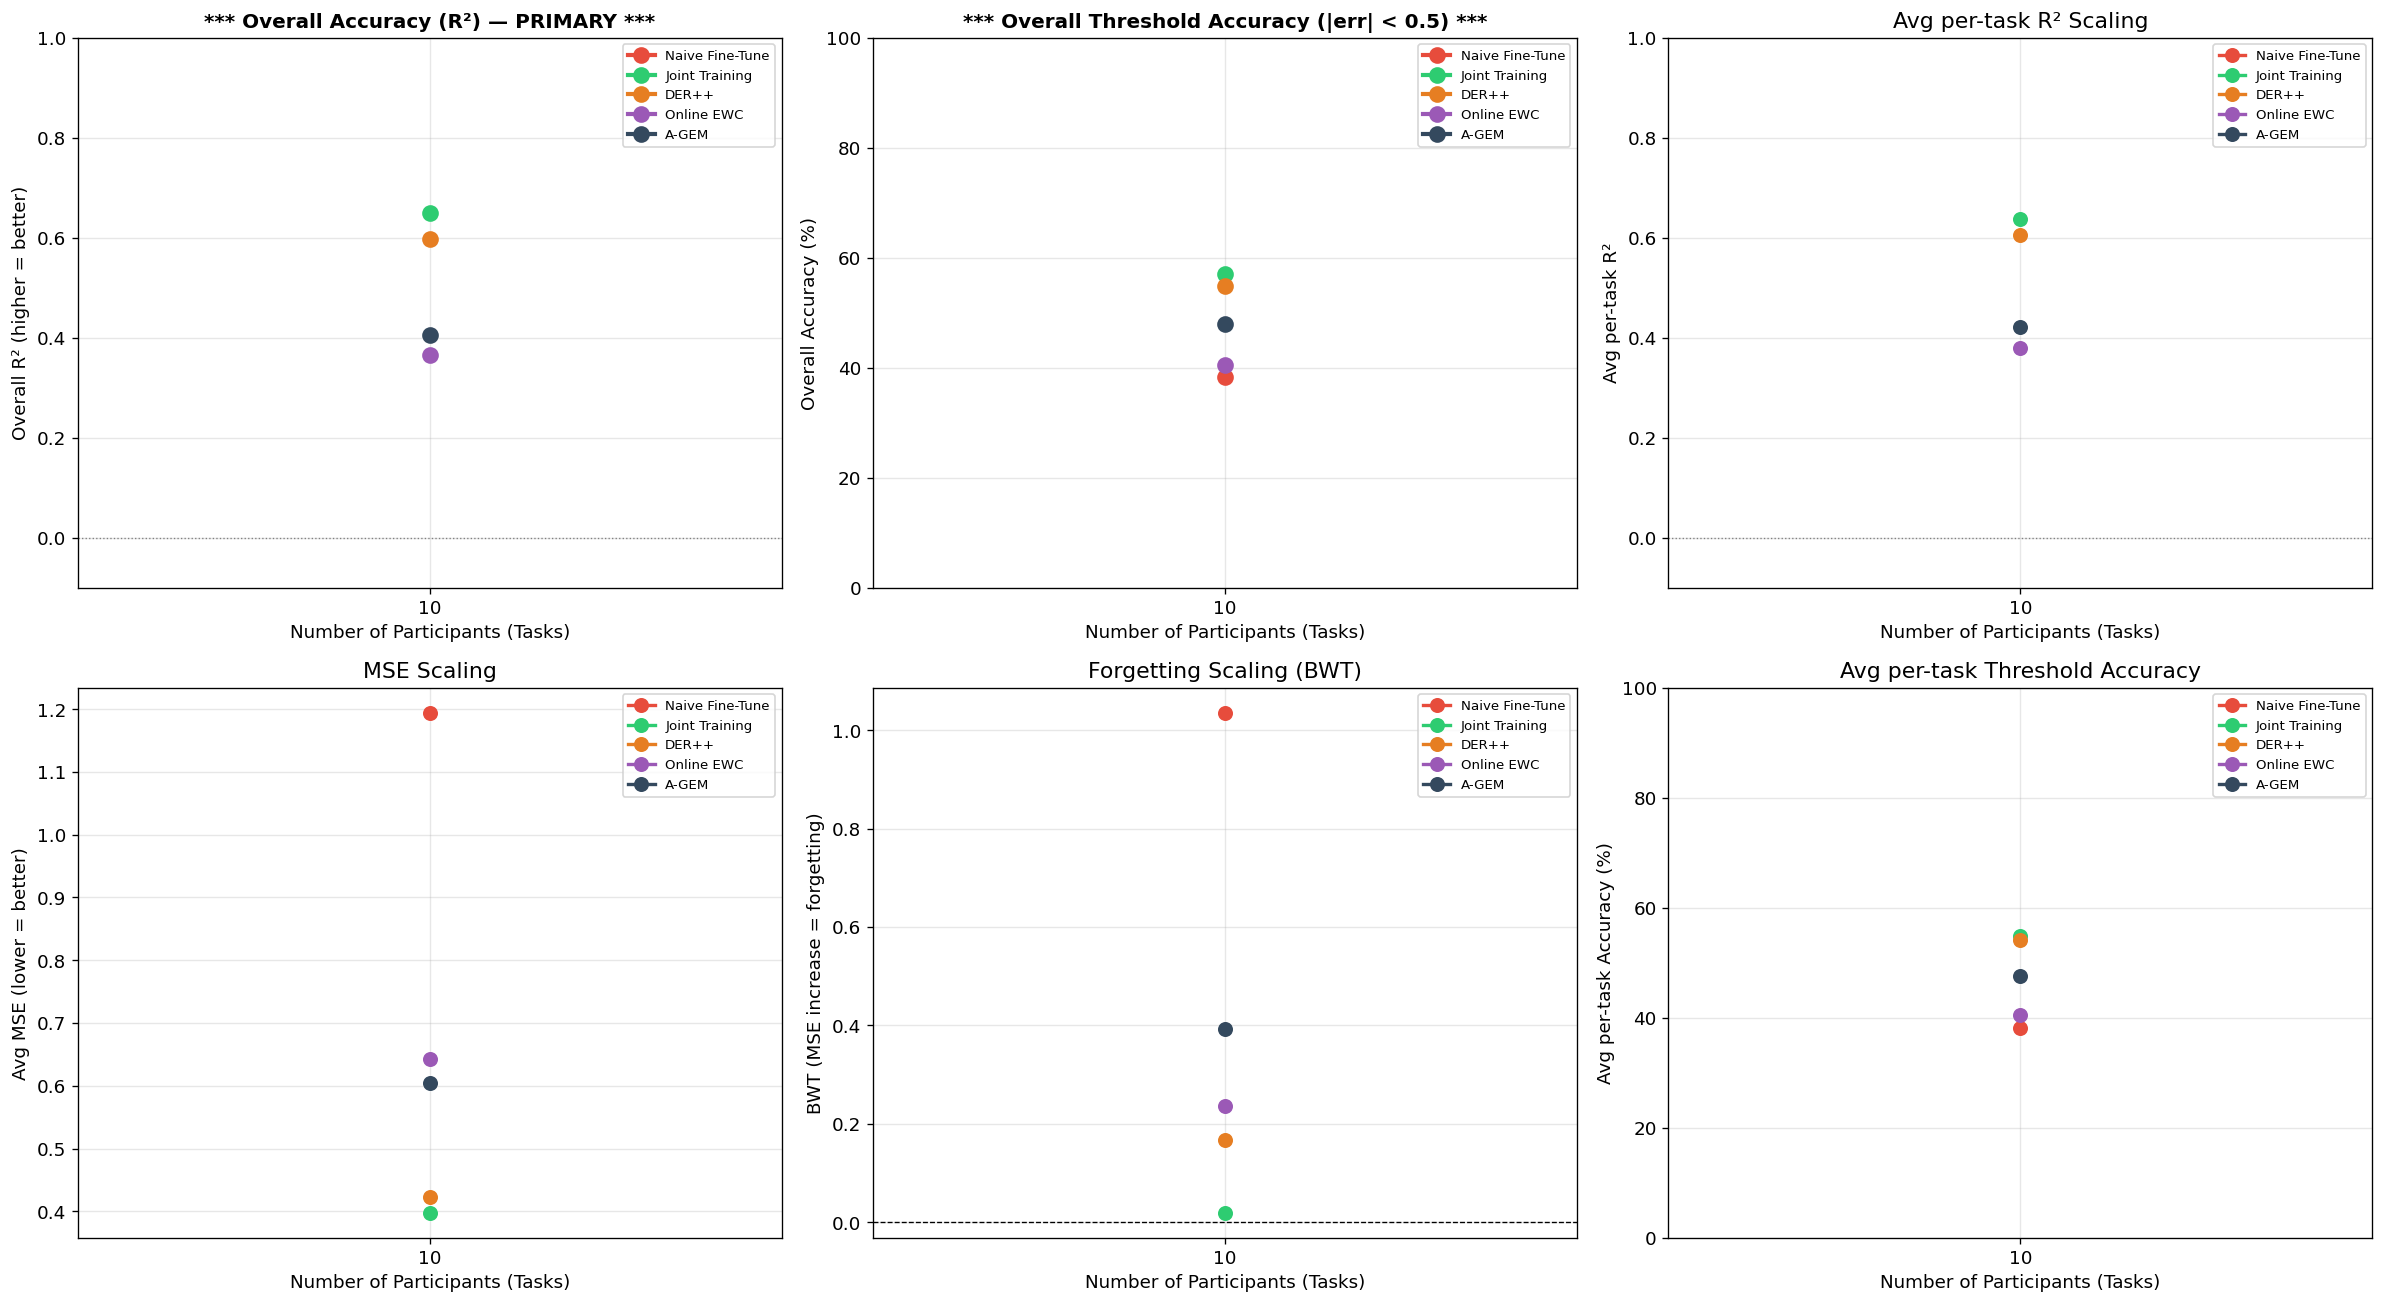

In [7]:
# Scalability Visualization

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
colors_s = {'Naive Fine-Tune': '#e74c3c', 'Joint Training': '#2ecc71',
            'DER++': '#e67e22', 'Online EWC': '#9b59b6', 'A-GEM': '#34495e'}

# Plot 1: Overall R² — PRIMARY METRIC
ax = axes[0, 0]
for strat in scale_strategies:
    vals = [scale_results[n][strat]['overall_r2'] for n in scales if strat in scale_results[n]]
    ns = [n for n in scales if strat in scale_results[n]]
    ax.plot(ns, vals, 'o-', label=strat, color=colors_s[strat], linewidth=2.5, markersize=9)
ax.set_xlabel('Number of Participants (Tasks)')
ax.set_ylabel('Overall R² (higher = better)')
ax.set_title('*** Overall Accuracy (R²) — PRIMARY ***', fontweight='bold', fontsize=12)
ax.set_xticks(scales)
ax.set_ylim(-0.1, 1.0)
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: Overall Threshold Accuracy
ax = axes[0, 1]
for strat in scale_strategies:
    vals = [scale_results[n][strat]['overall_accuracy'] for n in scales if strat in scale_results[n]]
    ns = [n for n in scales if strat in scale_results[n]]
    ax.plot(ns, vals, 'o-', label=strat, color=colors_s[strat], linewidth=2.5, markersize=9)
ax.set_xlabel('Number of Participants (Tasks)')
ax.set_ylabel('Overall Accuracy (%)')
ax.set_title(f'*** Overall Threshold Accuracy (|err| < {ACCURACY_THRESHOLD}) ***', fontweight='bold', fontsize=12)
ax.set_xticks(scales)
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 3: Avg per-task R²
ax = axes[0, 2]
for strat in scale_strategies:
    vals = [scale_results[n][strat]['avg_r2'] for n in scales if strat in scale_results[n]]
    ns = [n for n in scales if strat in scale_results[n]]
    ax.plot(ns, vals, 'o-', label=strat, color=colors_s[strat], linewidth=2, markersize=8)
ax.set_xlabel('Number of Participants (Tasks)')
ax.set_ylabel('Avg per-task R²')
ax.set_title('Avg per-task R² Scaling')
ax.set_xticks(scales)
ax.set_ylim(-0.1, 1.0)
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 4: MSE vs # participants
ax = axes[1, 0]
for strat in scale_strategies:
    mses = [scale_results[n][strat]['avg_mse'] for n in scales if strat in scale_results[n]]
    ns = [n for n in scales if strat in scale_results[n]]
    ax.plot(ns, mses, 'o-', label=strat, color=colors_s[strat], linewidth=2, markersize=8)
ax.set_xlabel('Number of Participants (Tasks)')
ax.set_ylabel('Avg MSE (lower = better)')
ax.set_title('MSE Scaling')
ax.set_xticks(scales)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 5: BWT vs # participants
ax = axes[1, 1]
for strat in scale_strategies:
    bwts = [scale_results[n][strat]['bwt'] for n in scales if strat in scale_results[n]]
    ns = [n for n in scales if strat in scale_results[n]]
    ax.plot(ns, bwts, 'o-', label=strat, color=colors_s[strat], linewidth=2, markersize=8)
ax.set_xlabel('Number of Participants (Tasks)')
ax.set_ylabel('BWT (MSE increase = forgetting)')
ax.set_title('Forgetting Scaling (BWT)')
ax.set_xticks(scales)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 6: Avg per-task Threshold Accuracy
ax = axes[1, 2]
for strat in scale_strategies:
    vals = [scale_results[n][strat]['avg_accuracy'] for n in scales if strat in scale_results[n]]
    ns = [n for n in scales if strat in scale_results[n]]
    ax.plot(ns, vals, 'o-', label=strat, color=colors_s[strat], linewidth=2, markersize=8)
ax.set_xlabel('Number of Participants (Tasks)')
ax.set_ylabel('Avg per-task Accuracy (%)')
ax.set_title(f'Avg per-task Threshold Accuracy')
ax.set_xticks(scales)
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/scalability_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Scalability Summary Table -- OVERALL MODEL ACCURACY AS PRIMARY METRIC
print('='*100)
print('SCALABILITY ANALYSIS — RANKED BY OVERALL MODEL ACCURACY (Pooled R²)')
print('='*100)

for n in scales:
    print(f'\n--- {n} Participants (ranked by Overall R²) ---')
    print(f'{"Rank":>4s}  {"Strategy":20s}  {"Ovrl R²":>8s}  {"Ovrl Acc%":>9s}  '
          f'{"Avg R²":>7s}  {"Avg Acc%":>8s}  {"MSE":>8s}  {"BWT":>8s}  {"Time":>8s}')
    print('-' * 95)
    # Sort by overall R² descending (higher is better)
    strats_sorted = sorted(scale_strategies,
                           key=lambda s: scale_results[n][s]['overall_r2'] if s in scale_results[n] else -1,
                           reverse=True)
    for rank, strat in enumerate(strats_sorted, 1):
        if strat in scale_results[n]:
            d = scale_results[n][strat]
            print(f'{rank:4d}  {strat:20s}  {d["overall_r2"]:8.4f}  {d["overall_accuracy"]:8.1f}%  '
                  f'{d["avg_r2"]:7.4f}  {d["avg_accuracy"]:7.1f}%  '
                  f'{d["avg_mse"]:8.4f}  {d["bwt"]:+8.4f}  {d["time"]:7.0f}s')

SCALABILITY ANALYSIS — RANKED BY OVERALL MODEL ACCURACY (Pooled R²)

--- 10 Participants (ranked by Overall R²) ---
Rank  Strategy               Ovrl R²  Ovrl Acc%   Avg R²  Avg Acc%       MSE       BWT      Time
-----------------------------------------------------------------------------------------------
   1  Joint Training          0.6490      56.9%   0.6377     54.8%    0.3978   +0.0192     6925s
   2  DER++                   0.5972      54.8%   0.6056     54.1%    0.4223   +0.1662      153s
   3  A-GEM                   0.4059      47.9%   0.4205     47.6%    0.6051   +0.3935      128s
   4  Online EWC              0.3655      40.5%   0.3783     40.4%    0.6426   +0.2363      119s
   5  Naive Fine-Tune        -0.1655      38.3%  -0.1921     38.1%    1.1943   +1.0356       93s


In [13]:
# Save config
config = {
    'experiment': 'scalability_analysis',
    'scales': scales,
    'strategies': scale_strategies,
    'hidden': list(HIDDEN), 'lr': LR, 'dropout': DROPOUT,
    'epochs': EPOCHS, 'patience': PATIENCE, 'batch_size': BS,
    'ewc_lambda': EWC_LAMBDA, 'oewc_gamma': OEWC_GAMMA,
    'der_buffer': DER_BUFFER, 'agem_mem': AGEM_MEM,
    'seed': SEED, 'device': DEVICE,
}
with open(f'{RESULTS_DIR}/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('All results saved to:', RESULTS_DIR)
for f_name in sorted(os.listdir(RESULTS_DIR)):
    size = os.path.getsize(os.path.join(RESULTS_DIR, f_name))
    print(f'  {f_name:45s} {size/1024:.1f} KB')

All results saved to: /home/g0amer/Desktop/thesis/phd_project/thesis_project/experiments/exp05_scalability
  config.json                                   0.4 KB
  scalability_plots.png                         196.9 KB
  scalability_results.json                      1.9 KB


---
## Summary

### Overall Model Accuracy (Pooled R² — Primary Metric)

| Rank | Strategy | Overall R² | Overall Acc% |
|------|----------|-----------|-------------|
| 1 | Joint Training | 0.6490 | 56.9% |
| 2 | DER++ | 0.5972 | 54.8% |
| 3 | A-GEM | 0.4059 | 47.9% |
| 4 | Online EWC | 0.3655 | 40.5% |
| 5 | Naive Fine-Tune | -0.1655 | 38.3% |

### Avg per-task Metrics

| Strategy | Avg R² | Avg Acc% | Avg MSE | BWT (MSE) | R² BWT |
|----------|--------|----------|---------|-----------|--------|
| Joint Training | 0.6377 | 54.8% | 0.3978 | +0.0192 | -0.0128 |
| DER++ | 0.6056 | 54.1% | 0.4223 | +0.1662 | -0.1518 |
| A-GEM | 0.4205 | 47.6% | 0.6051 | +0.3935 | -0.3797 |
| Online EWC | 0.3783 | 40.4% | 0.6426 | +0.2363 | -0.2492 |
| Naive Fine-Tune | -0.1921 | 38.1% | 1.1943 | +1.0356 | -1.0484 |

### Training Time

| Strategy | Time |
|----------|------|
| Naive Fine-Tune | 93s |
| Online EWC | 119s |
| A-GEM | 128s |
| DER++ | 153s |
| Joint Training | 6925s (~115 min) |

### Key Findings

1. **Joint Training achieves the highest overall accuracy** (R²=0.649, Acc=56.9%), serving as the upper bound, but at extreme computational cost (~115 min vs <3 min for others).
2. **DER++ is the best incremental strategy**, reaching R²=0.597 and 54.8% accuracy — only ~8% below Joint Training in R², while being 45x faster.
3. **A-GEM ranks 3rd** (R²=0.406, Acc=47.9%), offering decent accuracy with gradient projection but showing significant forgetting (R² BWT = -0.38).
4. **Online EWC ranks 4th** (R²=0.366, Acc=40.5%), with moderate forgetting (R² BWT = -0.25). Regularization alone is insufficient to fully preserve knowledge across 10 tasks.
5. **Naive Fine-Tune catastrophically forgets** (R²=-0.17), confirming it as the lower bound — the model essentially loses all prior knowledge.
6. **Forgetting severity ranking** (R² BWT): Naive (-1.05) >> A-GEM (-0.38) > Online EWC (-0.25) > DER++ (-0.15) > Joint (-0.01). DER++'s replay buffer is the most effective mechanism against forgetting among incremental methods.
7. **DER++ offers the best accuracy/cost trade-off** for deployment: near-Joint accuracy at a fraction of the training time, making it the recommended strategy for real HRC systems with 10 operators.